# Unit 6 code companion: Causal Claims and Where the Data Came From

Build a confounder, a collider, and a mediator in worlds where you set the truth, then watch the same patterns show up in real data and in how the rows were collected in the first place.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

rent = pd.read_csv("https://richardson.byu.edu/220/rent.csv")
TRUTH = rent["Rent"].mean()
print(f"treating the rent listings as a population: true mean rent = {TRUTH:,.0f}")

treating the rent listings as a population: true mean rent = 35,010


## 2. A confounder: an effect that is not there



In [2]:
n = 4000
z = rng.normal(0, 1, n)                       # lurking variable
x = 0.8*z + rng.normal(0, 0.6, n)             # treatment, driven by z
y = 2.0*z + rng.normal(0, 1.0, n)             # outcome, driven by z, NOT by x

naive = sm.OLS(y, sm.add_constant(x)).fit()
adj = sm.OLS(y, sm.add_constant(np.column_stack([x, z]))).fit()
print(f"TRUE effect of x on y      : 0.000")
print(f"naive estimate             : {naive.params[1]:+.3f}  (t = {naive.tvalues[1]:6.1f})")
print(f"controlling for z          : {adj.params[1]:+.3f}  (t = {adj.tvalues[1]:6.1f})")

TRUE effect of x on y      : 0.000
naive estimate             : +1.599  (t =   65.4)
controlling for z          : +0.022  (t =    0.8)


## 1. A collider: making a correlation out of nothing

Two independent variables. Select on their sum, and they become related.

In [3]:
d1 = rng.integers(1, 7, 4000)
d2 = rng.integers(1, 7, 4000)
keep = (d1 + d2) >= 9

print(f"correlation among ALL rolls           : {np.corrcoef(d1, d2)[0,1]:+.3f}")
print(f"correlation among rolls summing to 9+ : {np.corrcoef(d1[keep], d2[keep])[0,1]:+.3f}")
print(f"\n{keep.sum()} of {len(d1)} rolls survived the filter")

correlation among ALL rolls           : -0.014
correlation among rolls summing to 9+ : -0.515

1142 of 4000 rolls survived the filter


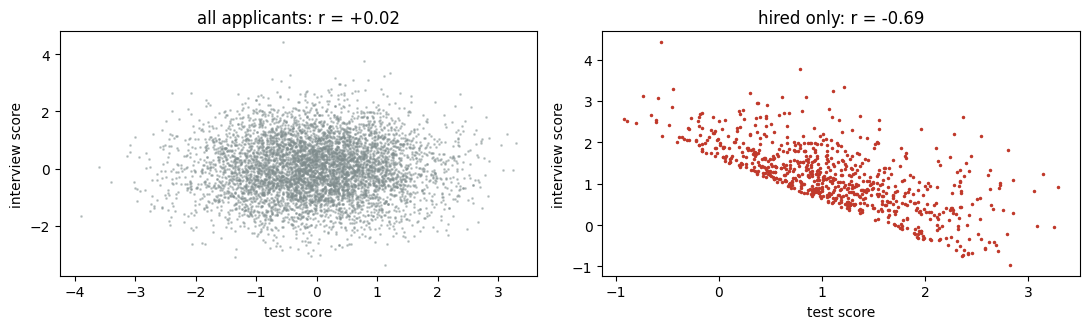

In [4]:
# The same structure with continuous variables: hiring on test + interview.
test = rng.normal(size=6000)
interview = rng.normal(size=6000)
hired = (test + interview) > 1.6

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(test, interview, ".", ms=2, color="#7f8c8d", alpha=.4)
axes[0].set_title(f"all applicants: r = {np.corrcoef(test, interview)[0,1]:+.2f}")
axes[1].plot(test[hired], interview[hired], ".", ms=3, color="#c0392b")
axes[1].set_title(f"hired only: r = {np.corrcoef(test[hired], interview[hired])[0,1]:+.2f}")
for ax in axes: ax.set_xlabel("test score"); ax.set_ylabel("interview score")
plt.tight_layout(); plt.show()

An HR analyst studying current employees would conclude that test performance and interview performance trade off against each other. They do not. The hiring rule created the pattern, and it exists only inside the hired group.

## 3. Survivorship: studying only what came back



In [5]:
n = 20_000
quality = rng.normal(0, 1, n)             # a startup's underlying quality
luck = rng.normal(0, 1, n)
survives = (quality + luck) > 1.2         # you only get to interview survivors

print(f"correlation(quality, luck) in ALL startups     : "
      f"{np.corrcoef(quality, luck)[0,1]:+.3f}")
print(f"correlation among SURVIVORS                    : "
      f"{np.corrcoef(quality[survives], luck[survives])[0,1]:+.3f}")
print(f"\nmean quality, all startups : {quality.mean():+.3f}")
print(f"mean quality, survivors      : {quality[survives].mean():+.3f}")
print("\nStudy only survivors and you will conclude that quality and luck are substitutes,")
print("and you will badly overestimate how much quality the average founder had.")

correlation(quality, luck) in ALL startups     : -0.006
correlation among SURVIVORS                    : -0.659

mean quality, all startups : -0.003
mean quality, survivors      : +0.993

Study only survivors and you will conclude that quality and luck are substitutes,
and you will badly overestimate how much quality the average founder had.


## 3. A mediator: controlling away a real effect



In [6]:
n = 4000
train = rng.integers(0, 2, n)                 # randomized training
skill = 1.5*train + rng.normal(0, 1, n)       # training raises skill
sales = 2.0*skill + rng.normal(0, 1, n)       # skill raises sales; no other path

total = sm.OLS(sales, sm.add_constant(train)).fit()
direct = sm.OLS(sales, sm.add_constant(np.column_stack([train, skill]))).fit()
print(f"TRUE total effect of training : {1.5*2.0:.2f}")
print(f"estimated total effect        : {total.params[1]:.3f}   <-- correct")
print(f"'controlling for skill'       : {direct.params[1]:.3f}   <-- the effect vanishes")

TRUE total effect of training : 3.00
estimated total effect        : 3.035   <-- correct
'controlling for skill'       : 0.003   <-- the effect vanishes


Training was randomized, so the total effect is unbiased. Controlling for skill blocks the only channel through which training works and reports approximately zero. Adding a variable is not a safe default: it is a claim about the causal structure.

## 4. The same story in real data



In [7]:
cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
raw = sm.OLS(cars.mpg, sm.add_constant(cars[["acceleration"]])).fit()
adj = sm.OLS(cars.mpg, sm.add_constant(cars[["acceleration", "weight"]])).fit()
print(f"raw slope on acceleration       : {raw.params['acceleration']:+.3f} mpg per second")
print(f"adjusting for weight            : {adj.params['acceleration']:+.3f} mpg per second")
print(f"share of the raw association that survived: "
      f"{adj.params['acceleration']/raw.params['acceleration']:.0%}")

raw slope on acceleration       : +1.198 mpg per second
adjusting for weight            : +0.262 mpg per second
share of the raw association that survived: 22%


## 1. Four sampling designs, scored against the truth

Only one kind of error shrinks with effort. The other is baked in.

In [8]:
def simple(n):
    return rent.sample(n).Rent.mean()

def convenience(n):
    # a scraper that only indexed smaller units
    small = rent[rent.Size <= rent.Size.median()]
    return small.sample(n).Rent.mean()

def cluster(n_cities=2, per=50):
    cities = rng.choice(rent.City.unique(), n_cities, replace=False)
    sub = rent[rent.City.isin(cities)]
    return sub.sample(min(n_cities*per, len(sub))).Rent.mean()

def stratified(n=100):
    parts = []
    for city, g in rent.groupby("City"):
        k = max(1, int(round(n * len(g)/len(rent))))
        parts.append(g.sample(min(k, len(g))).Rent)
    return pd.concat(parts).mean()

print(f"{'design':>14} {'mean estimate':>15} {'bias':>10} {'SD':>10} {'RMSE':>10}")
for name, fn in [("simple random", lambda: simple(100)),
                 ("convenience", lambda: convenience(100)),
                 ("cluster", cluster),
                 ("stratified", stratified)]:
    est = np.array([fn() for _ in range(600)])
    bias, sd = est.mean() - TRUTH, est.std()
    print(f"{name:>14} {est.mean():>15,.0f} {bias:>10,.0f} {sd:>10,.0f} "
          f"{np.sqrt(bias**2 + sd**2):>10,.0f}")

        design   mean estimate       bias         SD       RMSE
 simple random          35,170        160      7,869      7,870


   convenience          18,829    -16,181      1,948     16,298


       cluster          34,104       -906     18,816     18,837


    stratified          34,575       -435      7,739      7,751


Simple and stratified are both unbiased, and stratified is tighter for the same cost. Cluster is unbiased but far noisier, because two cities is closer to n=2 than n=100. Convenience is in a different category: it is *wrong*, and no sample size fixes it.

## 2. Bias does not shrink. Ever.



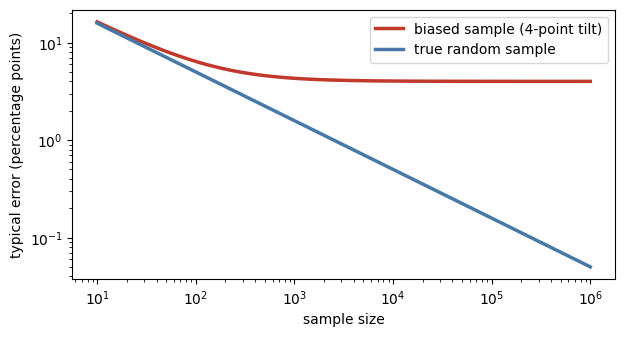

a RANDOM sample of 156 matches a biased sample of ANY size

with n = 1,000,000 from the biased process:
  reported 95% CI half-width : 0.098 points
  actual distance from truth : 4.0 points
  the interval is 25x too narrow to contain the truth. This is the dangerous case.


In [9]:
truth, bias = 0.50, 0.04
ns = np.logspace(1, 6, 60)
rmse_biased = np.sqrt(bias**2 + truth*(1-truth)/ns)
rmse_clean = np.sqrt(truth*(1-truth)/ns)

plt.loglog(ns, rmse_biased*100, color="#c0392b", lw=2.5, label="biased sample (4-point tilt)")
plt.loglog(ns, rmse_clean*100, color="#4878a8", lw=2.5, label="true random sample")
plt.xlabel("sample size"); plt.ylabel("typical error (percentage points)"); plt.legend(); plt.show()

n_equiv = truth*(1-truth)/bias**2
print(f"a RANDOM sample of {n_equiv:.0f} matches a biased sample of ANY size")
big_n = 1_000_000
se = np.sqrt(truth*(1-truth)/big_n)
print(f"\nwith n = {big_n:,} from the biased process:")
print(f"  reported 95% CI half-width : {1.96*se*100:.3f} points")
print(f"  actual distance from truth : {bias*100:.1f} points")
print("  the interval is 25x too narrow to contain the truth. This is the dangerous case.")

## 5. Missing values hiding as zeros, in real clinical data



In [10]:
dia = pd.read_csv("https://richardson.byu.edu/220/diabetes.csv")
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    z = (dia[col] == 0).sum()
    print(f"{col:>15}: {z:>4} zeros ({z/len(dia):5.1%}) "
          f"{'  <-- physiologically impossible' if z > 0 else ''}")

        Glucose:    5 zeros ( 0.7%)   <-- physiologically impossible
  BloodPressure:    0 zeros ( 0.0%) 
  SkinThickness:  194 zeros (26.5%)   <-- physiologically impossible
        Insulin:  339 zeros (46.2%)   <-- physiologically impossible
            BMI:    4 zeros ( 0.5%)   <-- physiologically impossible


In [11]:
ins_all = dia["Insulin"]
real = ins_all[ins_all > 0]
imputed = pd.concat([real, pd.Series([real.mean()]*int((ins_all == 0).sum()))])

print(f"{'approach':>28} {'mean':>9} {'SD':>9}")
print(f"{'keep the zeros (wrong)':>28} {ins_all.mean():>9.1f} {ins_all.std():>9.1f}")
print(f"{'drop them':>28} {real.mean():>9.1f} {real.std():>9.1f}")
print(f"{'impute the mean':>28} {imputed.mean():>9.1f} {imputed.std():>9.1f}")
print("\nMean imputation keeps the mean and shrinks the SD: it invents precision.")

# Is the missingness related to the outcome?
rate_missing = dia.loc[dia.Insulin == 0, "Outcome"].mean()
rate_present = dia.loc[dia.Insulin > 0, "Outcome"].mean()
print(f"\ndiabetes rate where insulin is MISSING : {rate_missing:.3f}")
print(f"diabetes rate where insulin is present  : {rate_present:.3f}")
print("If those differ, the missingness carries information and dropping rows changes the population.")

                    approach      mean        SD
      keep the zeros (wrong)      83.6     116.6
                   drop them     155.5     118.8
             impute the mean     155.5      87.0

Mean imputation keeps the mean and shrinks the SD: it invents precision.

diabetes rate where insulin is MISSING : 0.360
diabetes rate where insulin is present  : 0.330
If those differ, the missingness carries information and dropping rows changes the population.


## 5. Difference in differences, and what breaks it



In [12]:
def did(treat_effect, common_trend, pre_gap=12.0, n=400, treated_drift=0.0):
    """treated_drift lets us violate parallel trends on purpose."""
    ctrl_pre  = rng.normal(30, 5, n)
    ctrl_post = ctrl_pre + common_trend + rng.normal(0, 3, n)
    trt_pre   = rng.normal(30 + pre_gap, 5, n)
    trt_post  = trt_pre + common_trend + treated_drift + treat_effect + rng.normal(0, 3, n)
    return ((trt_post.mean() - trt_pre.mean()) - (ctrl_post.mean() - ctrl_pre.mean()))

print(f"true effect 7, parallel trends hold      : DiD = {did(7, 6):.2f}")
print(f"true effect 0, parallel trends hold      : DiD = {did(0, 6):.2f}")
print(f"true effect 0, treated region drifting +5: DiD = {did(0, 6, treated_drift=5):.2f}  <-- fake effect")
print("\nA before/after comparison in the treated region alone would have reported:")
print(f"  {did(7, 6) + 6:.2f} instead of 7, crediting the common trend to the treatment.")

true effect 7, parallel trends hold      : DiD = 6.58
true effect 0, parallel trends hold      : DiD = 0.03
true effect 0, treated region drifting +5: DiD = 5.09  <-- fake effect

A before/after comparison in the treated region alone would have reported:
  13.09 instead of 7, crediting the common trend to the treatment.
